In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## PUNTO 1

In [5]:
# =========================
# 1) Leer datos
# =========================
data = np.loadtxt("boston.txt")

year = int(data[0])
rain = data[1:]

N = len(rain)

# =========================
# 2) Construir eje temporal
# =========================
dt = 15  # segundos
time_seconds = np.arange(N) * dt
time_hours = time_seconds / 3600

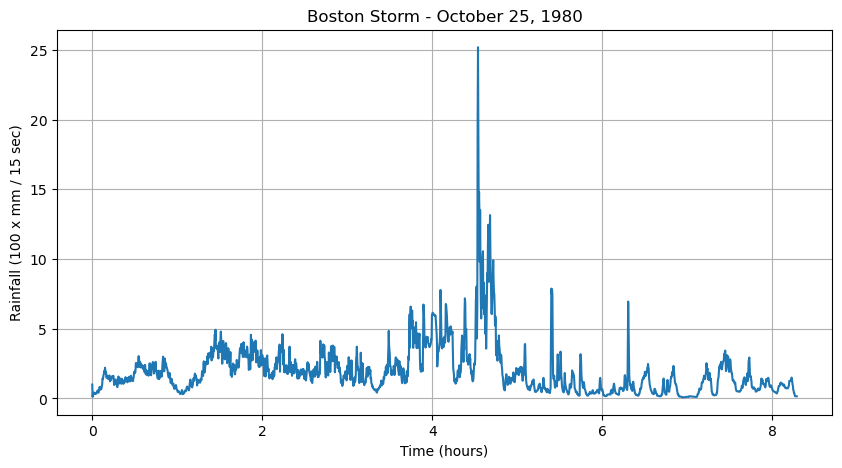

In [6]:
# =========================
# 3) Gráfica tipo artículo
# =========================
plt.figure(figsize=(10,5))
plt.plot(time_hours, rain)

plt.xlabel("Time (hours)")
plt.ylabel("Rainfall (100 x mm / 15 sec)")
plt.title("Boston Storm - October 25, 1980")
plt.grid(True)

plt.show()

In [7]:
# Remover media
# =========================
rain_detrended = rain - np.mean(rain)

# =========================
# FFT
# =========================
fft_vals = np.fft.fft(rain_detrended)
freq = np.fft.fftfreq(N, d=15)  # frecuencia en Hz

power = (np.abs(fft_vals)**2) / N

# Solo frecuencias positivas
mask = freq > 0
freq_pos = freq[mask]
power_pos = power[mask]

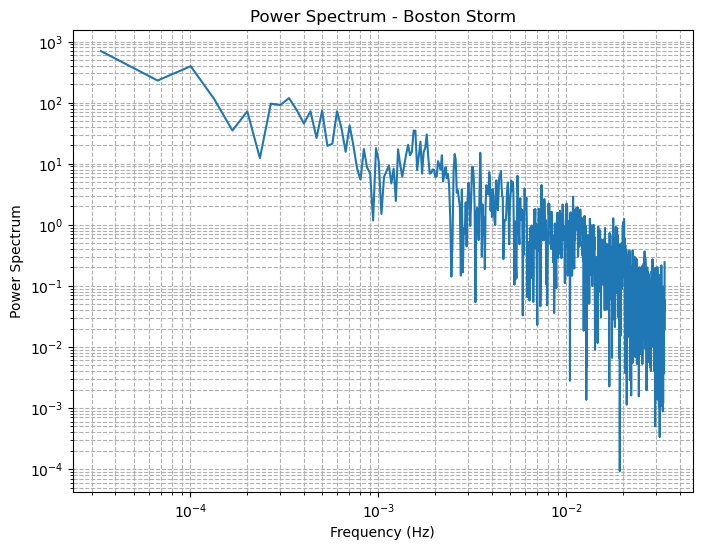

In [9]:
# =========================
# Gráfica espectro
# =========================
plt.figure(figsize=(8,6))
plt.loglog(freq_pos, power_pos)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum - Boston Storm")
plt.grid(True, which="both", ls="--")

plt.show()

## PUNTO 2

In [34]:
df_q = pd.read_csv(r".\35107030_C.csv")

# Asegurar formato fecha
df_q["Fecha"] = pd.to_datetime(df_q["Fecha"])

# Ordenar
df_q = df_q.sort_values("Fecha")

# Indexar
df_q = df_q.set_index("Fecha")

# Agregar a diario (promedio)
df_daily = df_q["Valor"].resample("D").mean()

# Eliminar días sin datos
df_daily = df_daily.dropna()

print("Número de días:", len(df_daily))
print("Años aproximados:", len(df_daily)/365)

Número de días: 7958
Años aproximados: 21.802739726027397


In [32]:
q_mean = np.mean(q)
q_centered = q - q_mean

N = len(q_centered)

X = np.fft.fft(q_centered)

freq = np.fft.fftfreq(N, d=1)

power = (np.abs(X)**2) / N

mask = freq > 0
freq_pos = freq[mask]
power_pos = power[mask]

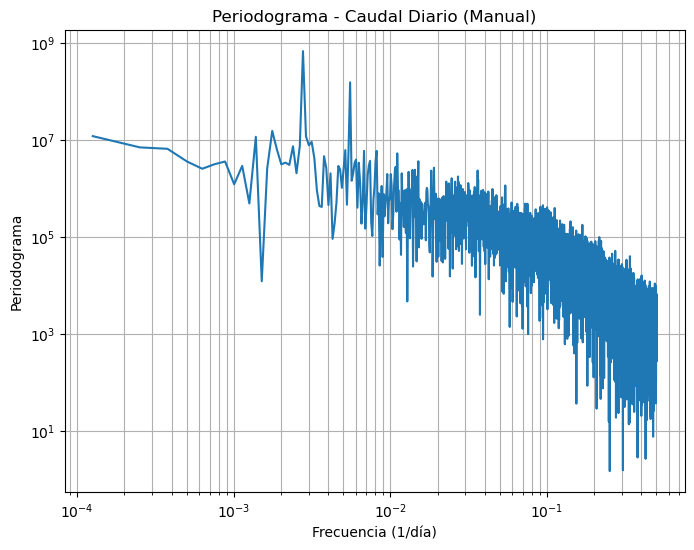

In [33]:
plt.figure(figsize=(8,6))
plt.loglog(freq_pos, power_pos)

plt.xlabel("Frecuencia (1/día)")
plt.ylabel("Periodograma")
plt.title("Periodograma - Caudal Diario (Manual)")
plt.grid(True, which="both")

plt.show()

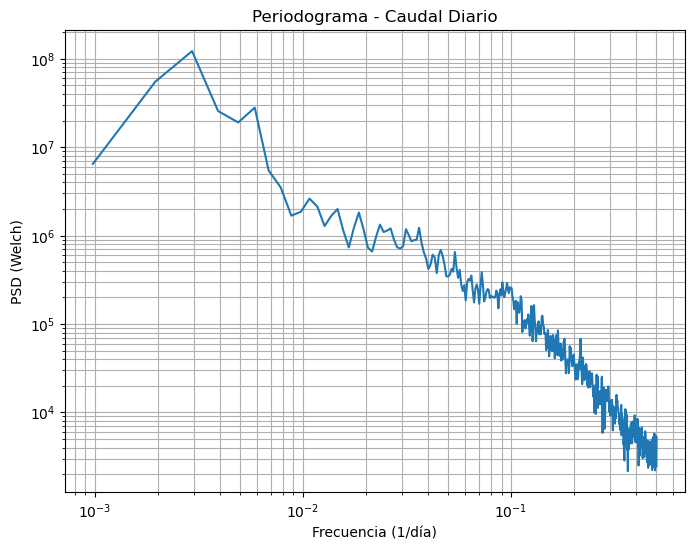

In [31]:
from scipy.signal import detrend, welch
import numpy as np
import matplotlib.pyplot as plt

q = df_daily.values

# Remover tendencia
q_detrended = detrend(q)

# Remover media
q_detrended = q_detrended - np.mean(q_detrended)

# Welch (recomendado)
freq_w, power_w = welch(q_detrended, fs=1, nperseg=1024)

plt.figure(figsize=(8,6))
plt.loglog(freq_w[1:], power_w[1:])
plt.xlabel("Frecuencia (1/día)")
plt.ylabel("PSD (Welch)")
plt.title("Periodograma - Caudal Diario")
plt.grid(True, which="both")
plt.show()

In [40]:
df_q = pd.read_csv(r".\35107030_P.csv")

# Asegurar formato fecha
df_q["Fecha"] = pd.to_datetime(df_q["Fecha"])

# Ordenar
df_q = df_q.sort_values("Fecha")

# Indexar
df_q = df_q.set_index("Fecha")

# Agregar a diario (promedio)
df_daily = df_q["Valor"].resample("D").mean()

# Eliminar días sin datos
df_daily = df_daily.dropna()

print("Número de días:", len(df_daily))
print("Años aproximados:", len(df_daily)/365)

Número de días: 9330
Años aproximados: 25.561643835616437


In [41]:
q_mean = np.mean(q)
q_centered = q - q_mean

N = len(q_centered)

X = np.fft.fft(q_centered)

freq = np.fft.fftfreq(N, d=1)

power = (np.abs(X)**2) / N

mask = freq > 0
freq_pos = freq[mask]
power_pos = power[mask]

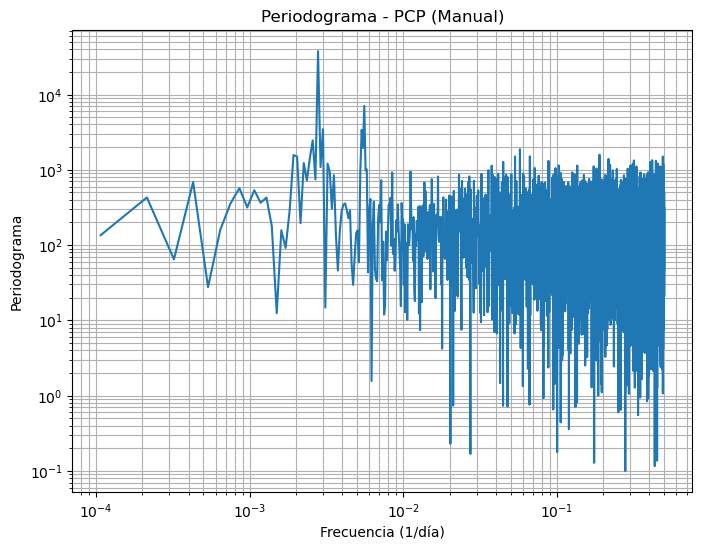

In [42]:
plt.figure(figsize=(8,6))
plt.loglog(freq_pos, power_pos)

plt.xlabel("Frecuencia (1/día)")
plt.ylabel("Periodograma")
plt.title("Periodograma - PCP (Manual)")
plt.grid(True, which="both")

plt.show()

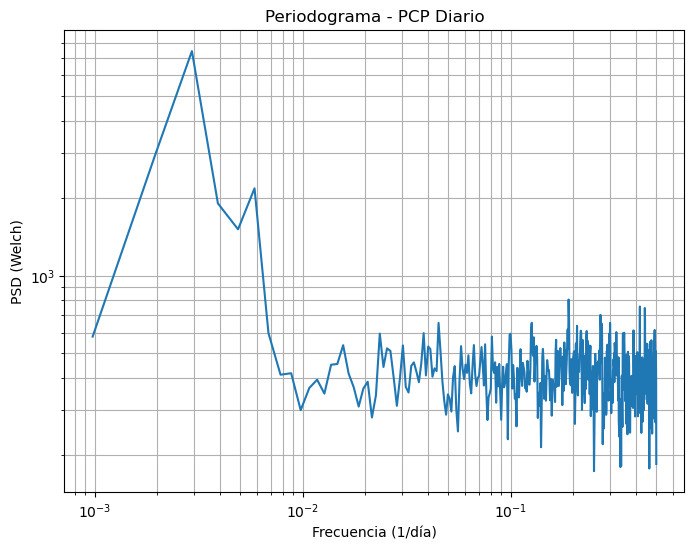

In [43]:
q = df_daily.values

# Remover tendencia
q_detrended = detrend(q)

# Remover media
q_detrended = q_detrended - np.mean(q_detrended)

# Welch (recomendado)
freq_w, power_w = welch(q_detrended, fs=1, nperseg=1024)

plt.figure(figsize=(8,6))
plt.loglog(freq_w[1:], power_w[1:])
plt.xlabel("Frecuencia (1/día)")
plt.ylabel("PSD (Welch)")
plt.title("Periodograma - PCP Diario")
plt.grid(True, which="both")
plt.show()

In [49]:
df_q = pd.read_csv(r".\Libertad_T.csv")

# Asegurar formato fecha
df_q["Fecha"] = pd.to_datetime(df_q["Fecha"])

# Ordenar
df_q = df_q.sort_values("Fecha")

# Indexar
df_q = df_q.set_index("Fecha")

# Agregar a diario (promedio)
df_daily = df_q["Valor"].resample("D").mean()

# Eliminar días sin datos
df_daily = df_daily.dropna()

print("Número de días:", len(df_daily))
print("Años aproximados:", len(df_daily)/365)

Número de días: 1630
Años aproximados: 4.465753424657534


In [50]:
q_mean = np.mean(q)
q_centered = q - q_mean

N = len(q_centered)

X = np.fft.fft(q_centered)

freq = np.fft.fftfreq(N, d=1)

power = (np.abs(X)**2) / N

mask = freq > 0
freq_pos = freq[mask]
power_pos = power[mask]

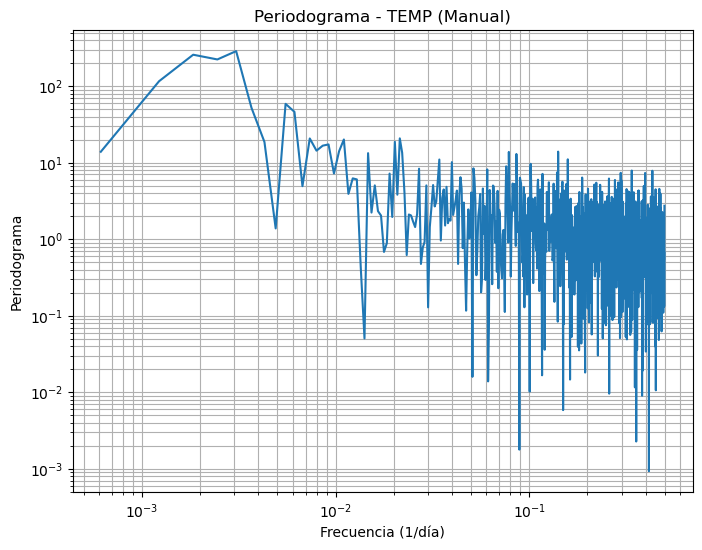

In [51]:
plt.figure(figsize=(8,6))
plt.loglog(freq_pos, power_pos)

plt.xlabel("Frecuencia (1/día)")
plt.ylabel("Periodograma")
plt.title("Periodograma - TEMP (Manual)")
plt.grid(True, which="both")

plt.show()

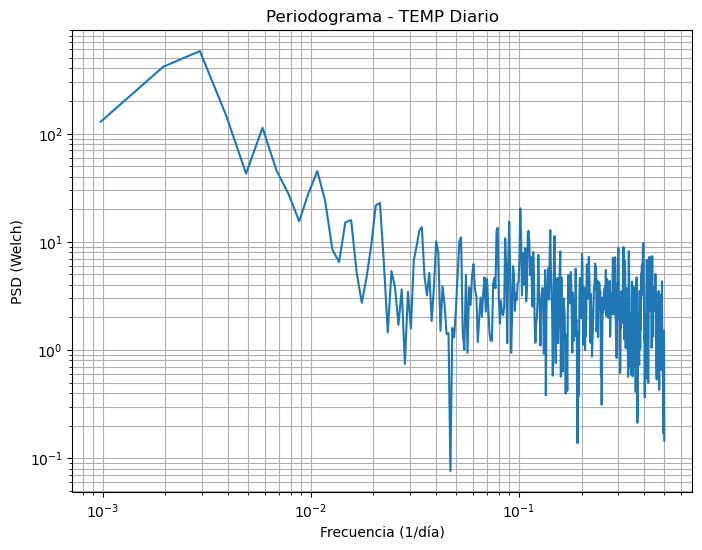

In [53]:
q = df_daily.values

# Remover tendencia
q_detrended = detrend(q)

# Remover media
q_detrended = q_detrended - np.mean(q_detrended)

# Welch (recomendado)
freq_w, power_w = welch(q_detrended, fs=1, nperseg=1024)

plt.figure(figsize=(8,6))
plt.loglog(freq_w[1:], power_w[1:])
plt.xlabel("Frecuencia (1/día)")
plt.ylabel("PSD (Welch)")
plt.title("Periodograma - TEMP Diario")
plt.grid(True, which="both")
plt.show()

## PUNTO 3

In [59]:
q = df_daily.values
N = len(q)

# Guardar media
media = np.mean(q)

# Centrar
x = q - media

# FFT
X = np.fft.fft(x)

# Energía espectral
power = (np.abs(X)**2) / N

In [60]:
# Varianza total
var_total = np.sum(power)

# Ordenar armónicos por energía
indices = np.argsort(power)[::-1]  # de mayor a menor

power_sorted = power[indices]

# Varianza acumulada
var_acum = np.cumsum(power_sorted) / var_total

In [61]:
X_100 = X.copy()

In [62]:
k_75 = np.where(var_acum >= 0.75)[0][0]

indices_75 = indices[:k_75+1]

X_75 = np.zeros_like(X, dtype=complex)
X_75[indices_75] = X[indices_75]

In [63]:
k_50 = np.where(var_acum >= 0.50)[0][0]

indices_50 = indices[:k_50+1]

X_50 = np.zeros_like(X, dtype=complex)
X_50[indices_50] = X[indices_50]

In [64]:
x_rec_100 = np.fft.ifft(X_100).real + media
x_rec_75  = np.fft.ifft(X_75).real + media
x_rec_50  = np.fft.ifft(X_50).real + media

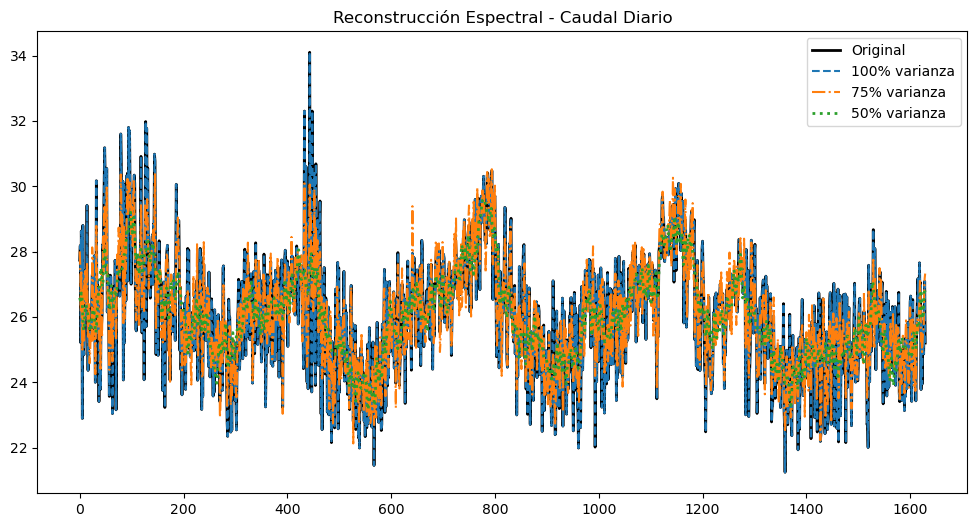

In [66]:
plt.figure(figsize=(12,6))

plt.plot(q, 
         label="Original", 
         color="black", 
         linewidth=2)

plt.plot(x_rec_100, 
         label="100% varianza", 
         linestyle="--", 
         linewidth=1.5)

plt.plot(x_rec_75, 
         label="75% varianza", 
         linestyle="-.", 
         linewidth=1.5)

plt.plot(x_rec_50, 
         label="50% varianza", 
         linestyle=":", 
         linewidth=2)

plt.legend()
plt.title("Reconstrucción Espectral - Caudal Diario")
plt.show()

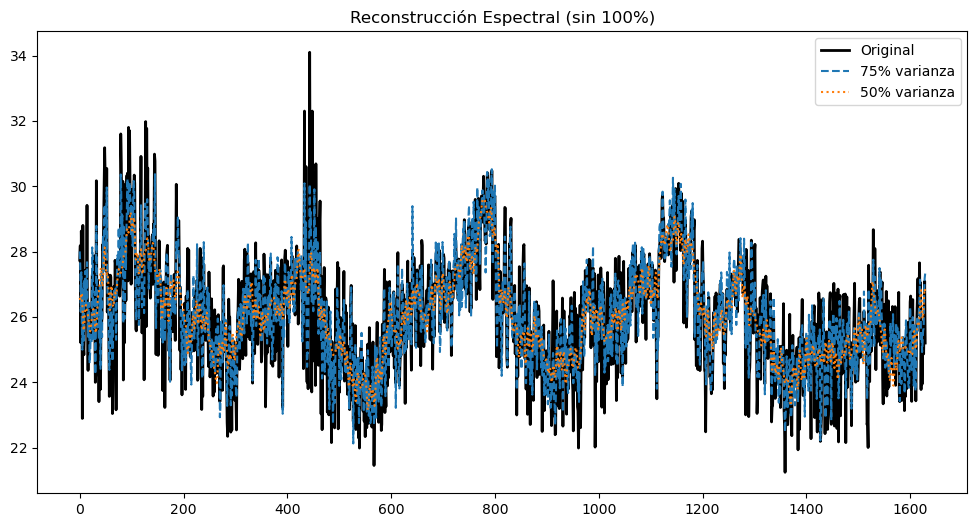

In [67]:
plt.figure(figsize=(12,6))

plt.plot(q, 
         label="Original", 
         color="black", 
         linewidth=2)

plt.plot(x_rec_75, 
         label="75% varianza", 
         linestyle="--")

plt.plot(x_rec_50, 
         label="50% varianza", 
         linestyle=":")

plt.legend()
plt.title("Reconstrucción Espectral (sin 100%)")
plt.show()

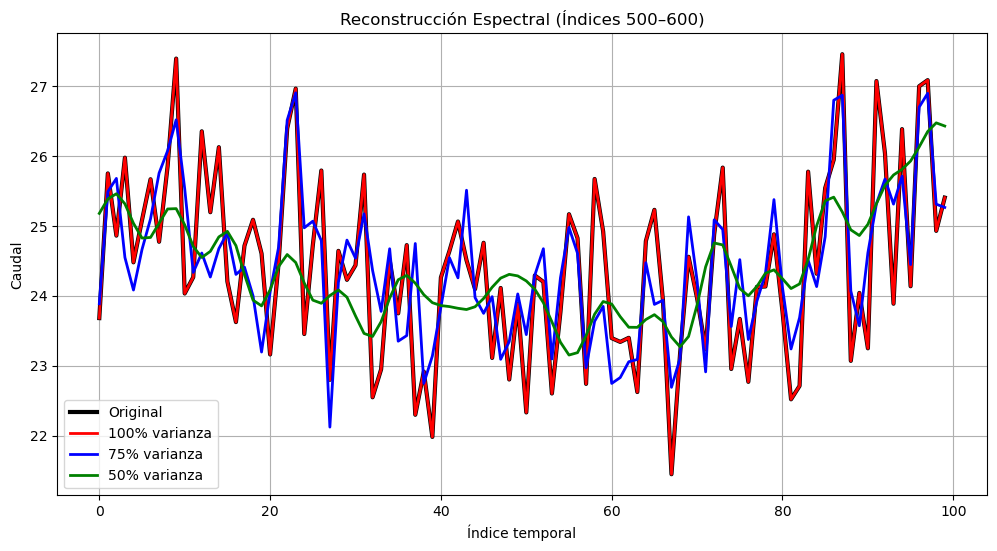

In [70]:
i0 = 500
i1 = 600

plt.figure(figsize=(12,6))

plt.plot(q[i0:i1], 
         label="Original", 
         color="black", 
         linewidth=3)

plt.plot(x_rec_100[i0:i1], 
         label="100% varianza", 
         color="red", 
         linewidth=2)

plt.plot(x_rec_75[i0:i1], 
         label="75% varianza", 
         color="blue", 
         linewidth=2)

plt.plot(x_rec_50[i0:i1], 
         label="50% varianza", 
         color="green", 
         linewidth=2)

plt.legend()
plt.title("Reconstrucción Espectral (Índices 500–600)")
plt.xlabel("Índice temporal")
plt.ylabel("Caudal")
plt.grid(True)

plt.show()

## PUNTO 4

In [71]:
df = pd.read_csv("./MedicionesSeptiembre.csv")

print(df.head())
print(df.columns)

                 Fecha         u         v         w       Ts
0  2014-09-01 00:00:00  0.366127  0.349315  0.066795  16.0360
1  2014-09-01 00:00:00  0.434309  0.315691  0.084582  16.0822
2  2014-09-01 00:00:00  0.401619  0.279265  0.065887  16.1062
3  2014-09-01 00:00:00  0.389477  0.308219  0.095654  16.1113
4  2014-09-01 00:00:00  0.443649  0.268991  0.119795  16.0890
Index(['Fecha', 'u', 'v', 'w', 'Ts'], dtype='str')


In [72]:
x = df["w"].dropna().values
N = len(x)

In [73]:
x = x - np.mean(x)

In [74]:
fs = 10      # Hz
dt = 1/fs

In [75]:
X = np.fft.fft(x)
freq = np.fft.fftfreq(N, d=dt)

power = (np.abs(X)**2) / N

In [76]:
mask = freq > 0

freq_pos = freq[mask]
power_pos = power[mask]

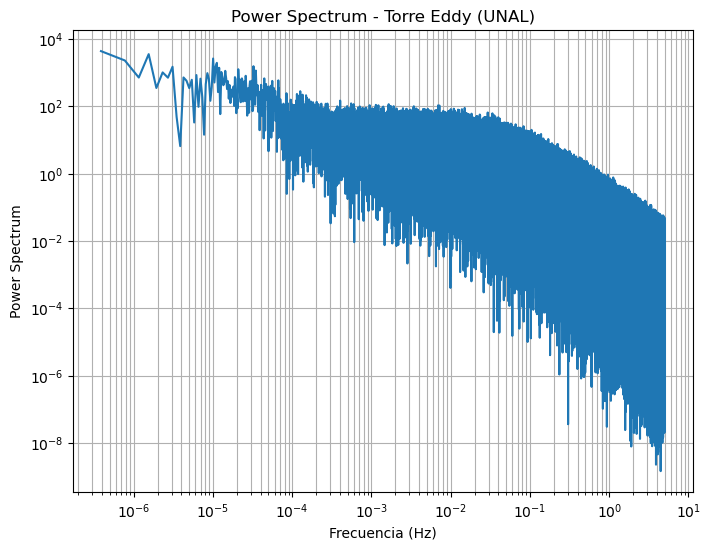

In [77]:
plt.figure(figsize=(8,6))

plt.loglog(freq_pos, power_pos)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum - Torre Eddy (UNAL)")
plt.grid(True, which="both")

plt.show()

c:\Users\USUARIO\anaconda3\envs\hydro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


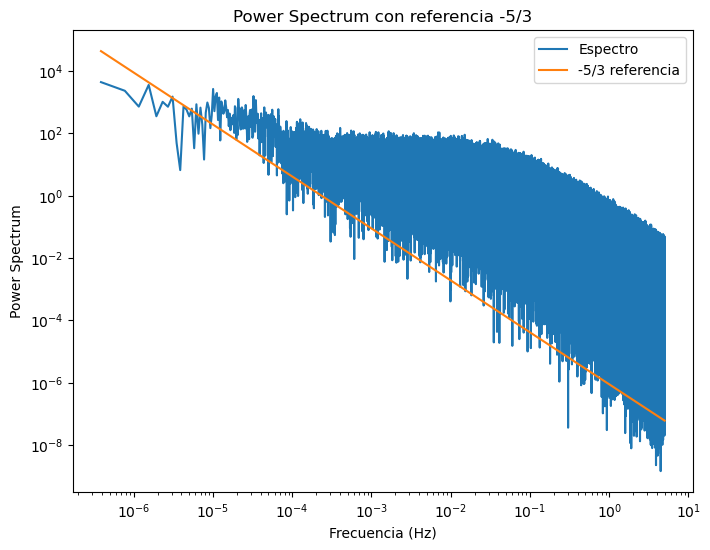

In [78]:
# Elegir punto base para línea teórica
f_ref = freq_pos[100]
P_ref = power_pos[100]

linea_kolm = P_ref * (freq_pos / f_ref)**(-5/3)

plt.figure(figsize=(8,6))
plt.loglog(freq_pos, power_pos, label="Espectro")
plt.loglog(freq_pos, linea_kolm, label="-5/3 referencia")

plt.legend()
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum con referencia -5/3")
plt.show()

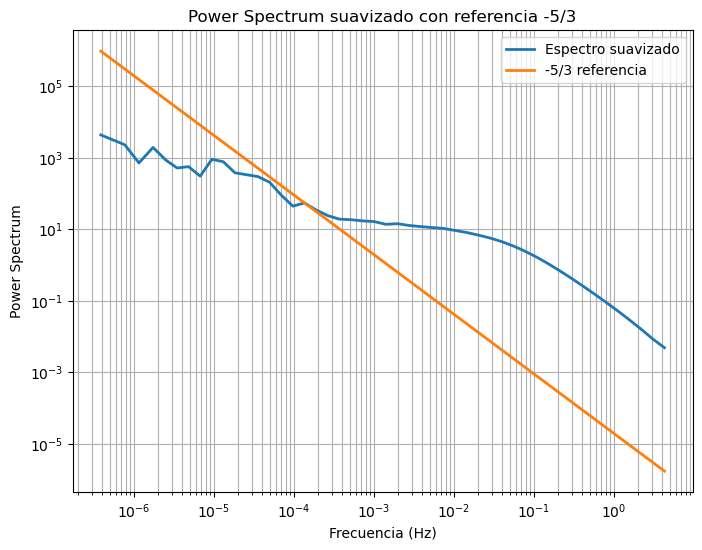

In [80]:
# --- Suavizado logarítmico ---
bins = np.logspace(np.log10(freq_pos.min()),
                   np.log10(freq_pos.max()),
                   50)

digitized = np.digitize(freq_pos, bins)

freq_s = []
power_s = []

for i in range(1, len(bins)):
    mask = digitized == i
    if np.sum(mask) > 0:
        freq_s.append(np.mean(freq_pos[mask]))
        power_s.append(np.mean(power_pos[mask]))

freq_s = np.array(freq_s)
power_s = np.array(power_s)

# --- Construir referencia -5/3 ---
# Elegimos un punto intermedio (evitar extremos)
idx_ref = len(freq_s)//3

f_ref = freq_s[idx_ref]
P_ref = power_s[idx_ref]

kolm_ref = P_ref * (freq_s / f_ref)**(-5/3)

# --- Graficar ---
plt.figure(figsize=(8,6))

plt.loglog(freq_s, power_s, linewidth=2, label="Espectro suavizado")
plt.loglog(freq_s, kolm_ref, linewidth=2, label="-5/3 referencia")

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum suavizado con referencia -5/3")
plt.legend()
plt.grid(True, which="both")

plt.show()